In [ ]:
from tools import *

path = Path('csv/departement-13-bouches-du-rhone/raster/2x2')

datacube = read_object('datacube.pkl', path)

In [ ]:
cols = ['temp',
 'dwpt',
 'rhum',
 'prcp',
 'wdir',
 'wspd',
 'snow',
 'prec24h',
 'snow24h',
 'dc',
 'ffmc',
 'dmc',
 'nesterov',
 'munger',
 'kbdi',
 'isi',
 'angstroem',
 'bui',
 'fwi',
 'dailySeverityRating',
 'temp16',
 'dwpt16',
 'rhum16',
 'prcp16',
 'wdir16',
 'wspd16',
 'prec24h16',
 'snow24h16',
 'days_since_rain',
 'sum_consecutive_rainfall',
 'sum_rain_last_7_days',
 'sum_snow_last_7_days',
 'corine_landcover',
 'Corine_Other',
 'Corine_urban',
 'Corine_transport',
 'Corine_agricultural',
 'Corine_grass',
 'Corine_forest',
 'Corine_vegetation',
 'Corine_moisture',
 'Corine_water',
 'Corine_littoral',
 'Corine_rock',
 'elevation',
 'population',
 'NDVI',
 'NDMI',
 'NDBI',
 'NDSI',
 'NDWI',
 'forest_landcover',
 'NoForest',
 'Châtaignier',
 'Chênes décidus',
 'Chênes sempervirents',
 'Conifères',
 'Douglas',
 'Feuillus',
 'Hêtre',
 'Mélèze',
 'Mixte',
 'NC',
 'NR',
 'Pin à crochets, pin cembro',
 'Pin autre',
 "Pin d'Alep",
 'Pin laricio, pin noir',
 'Pin maritime',
 'Pin sylvestre',
 'Pins mélangés',
 'Peuplier',
 'Robinier',
 'Sapin, épicéa',
 'route_landcover',
 'NoRoad',
 'Road']

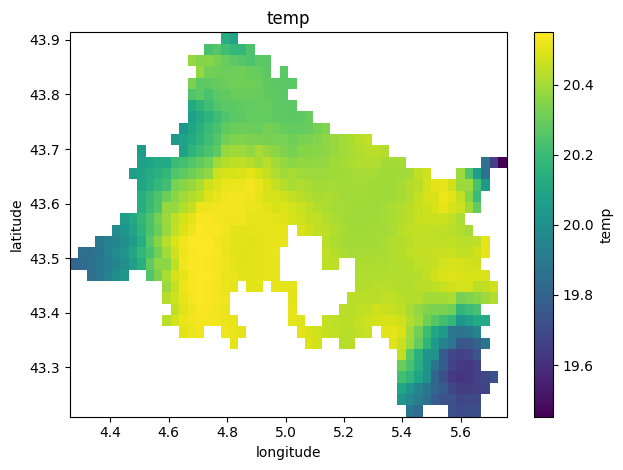

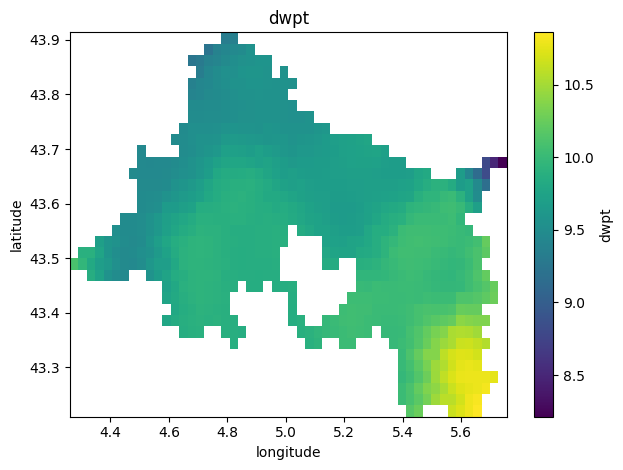

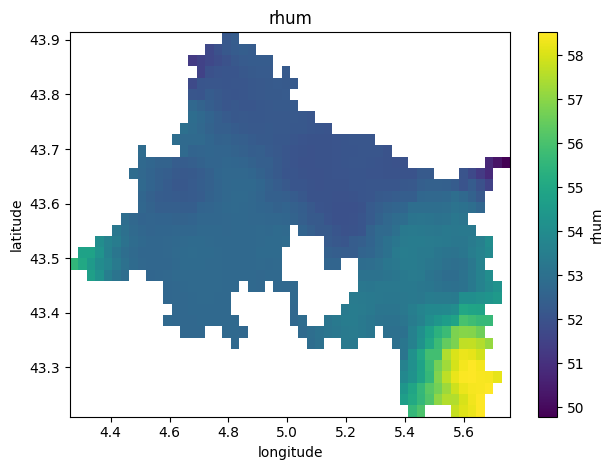

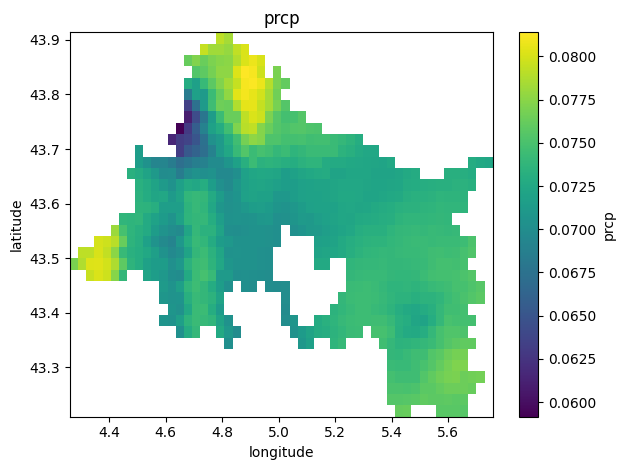

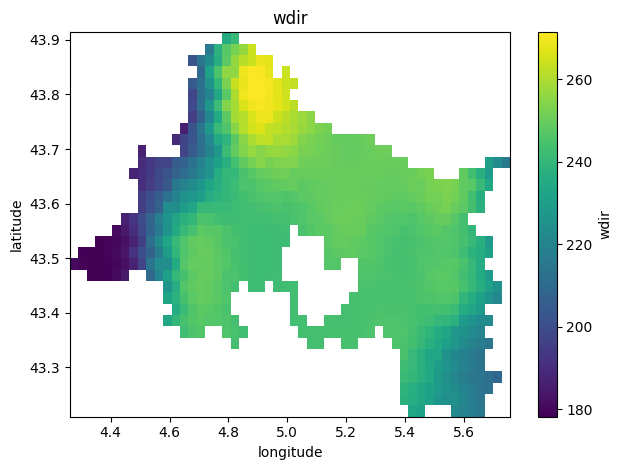

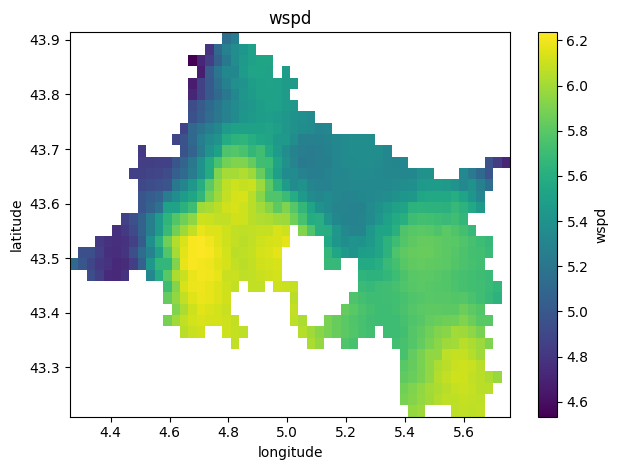

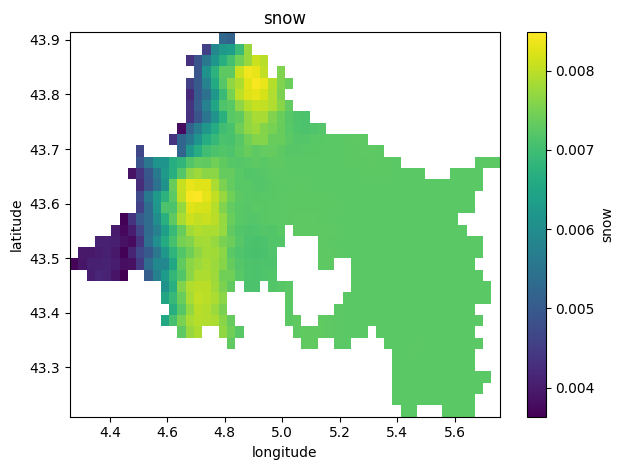

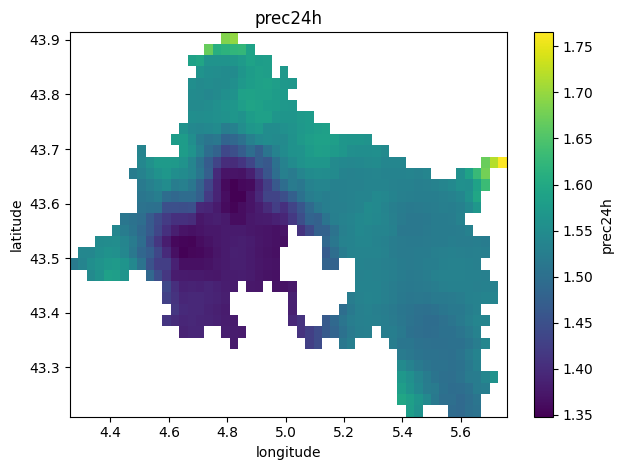

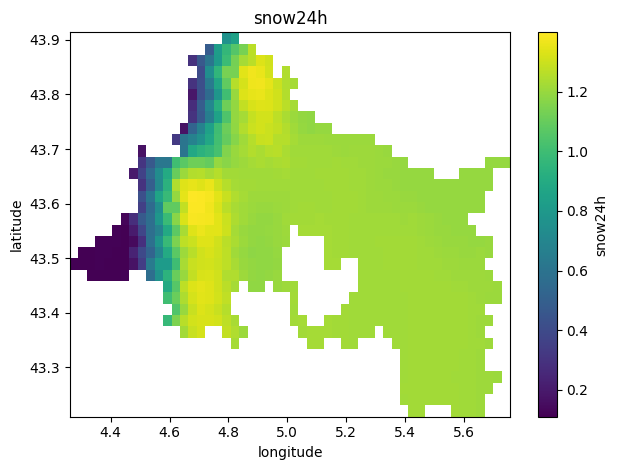

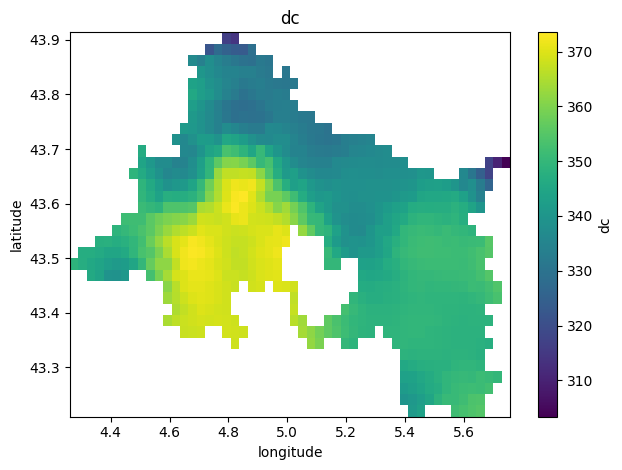

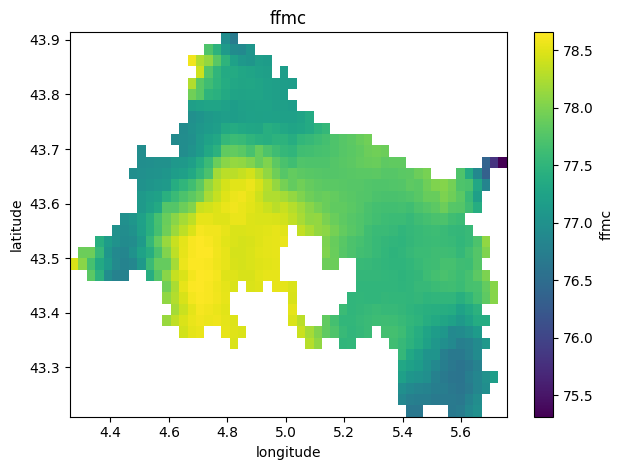

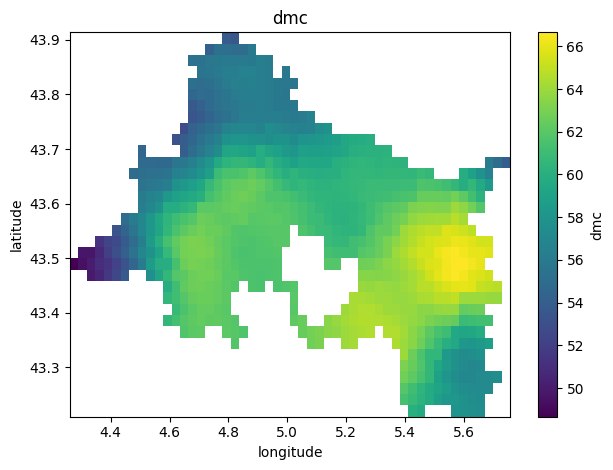

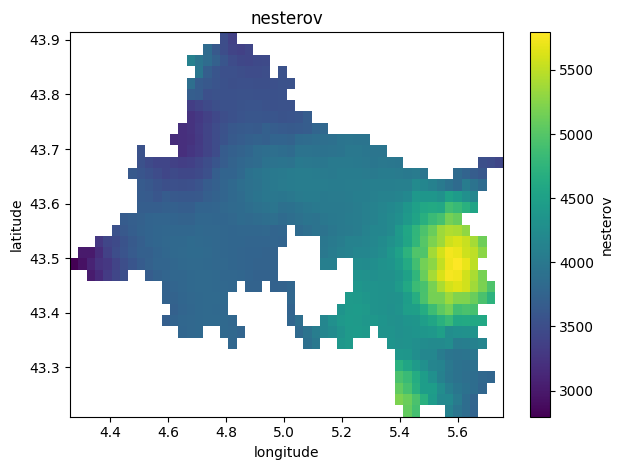

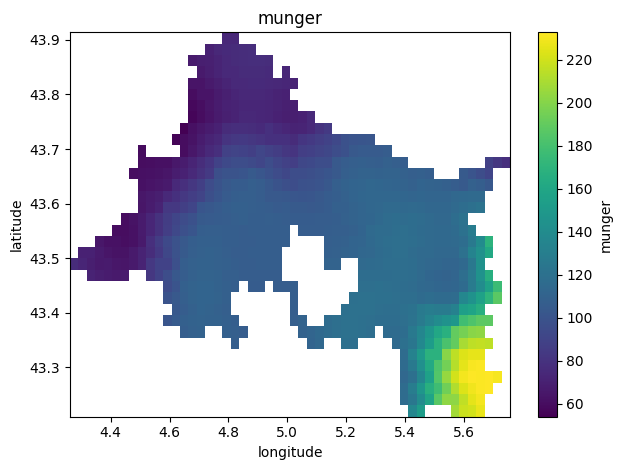

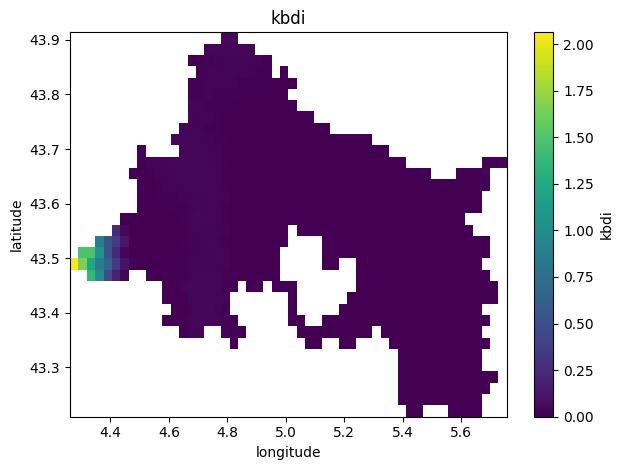

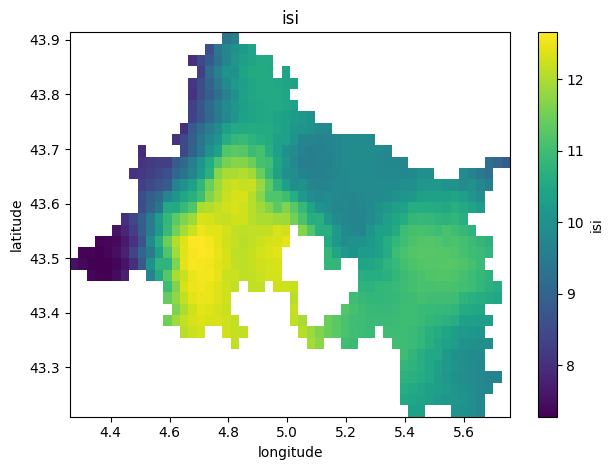

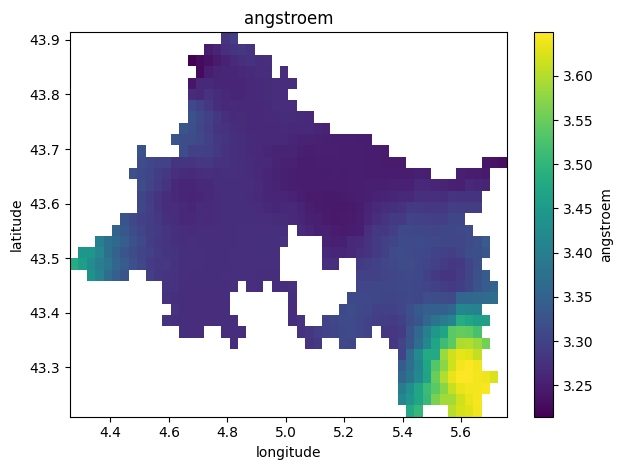

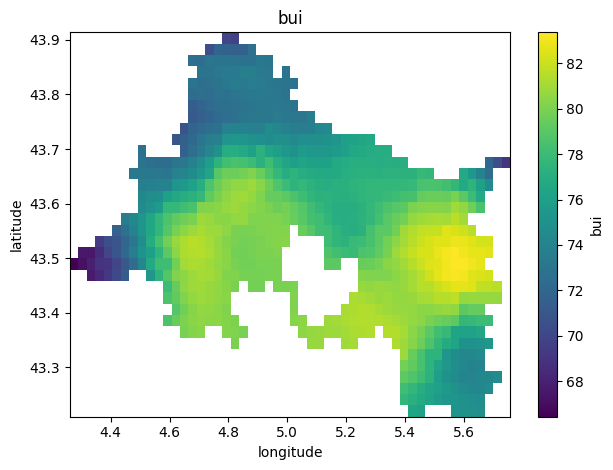

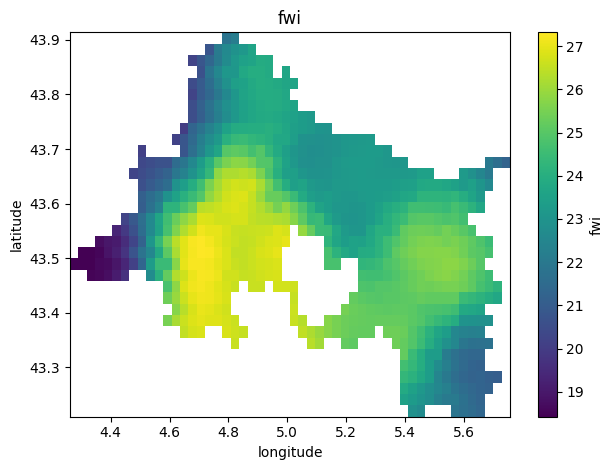

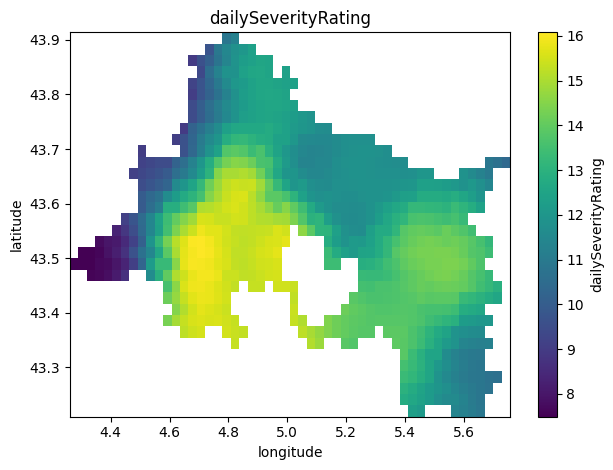

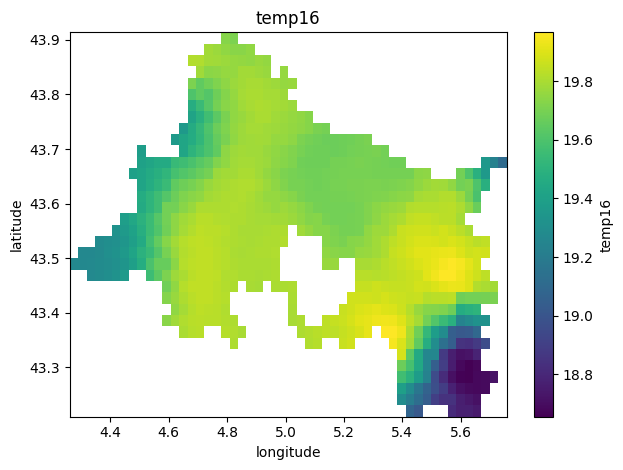

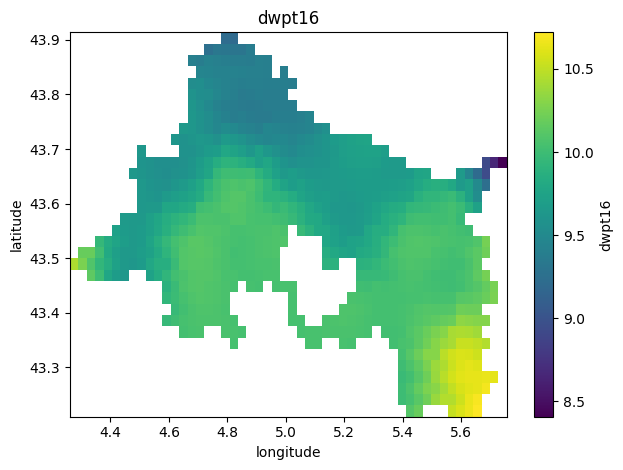

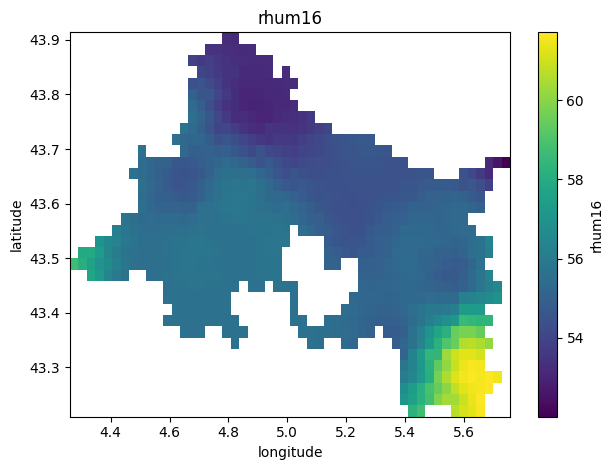

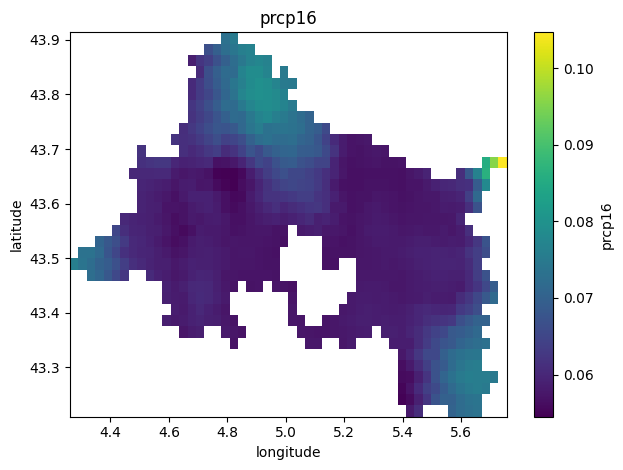

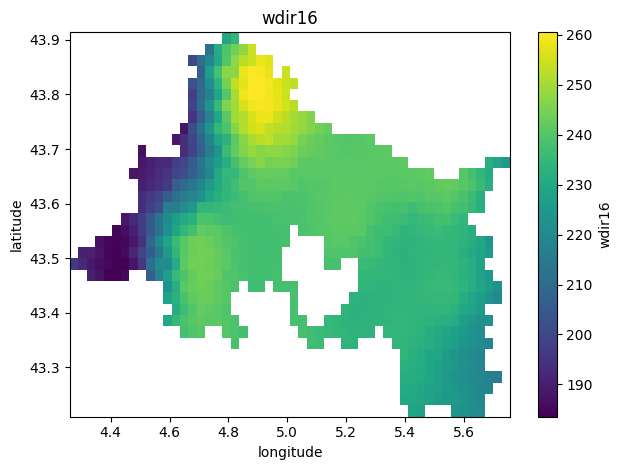

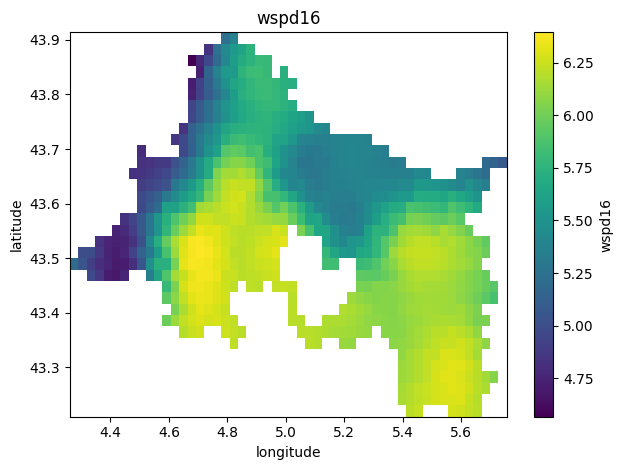

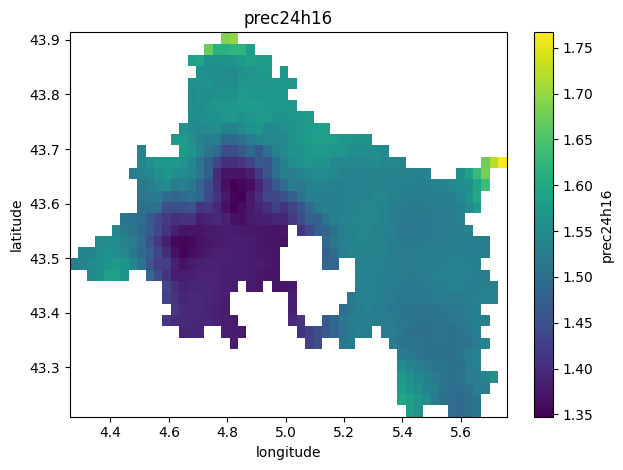

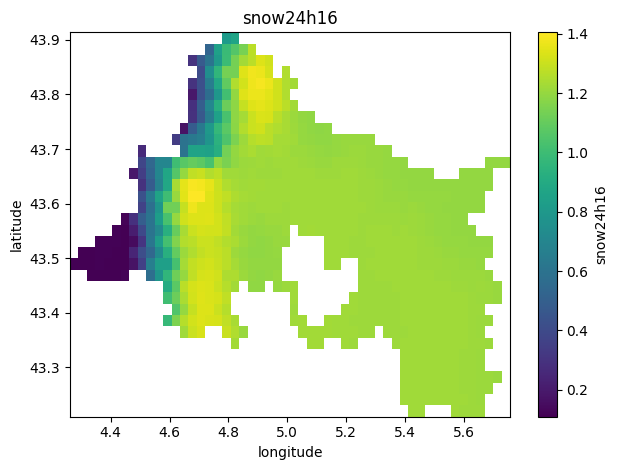

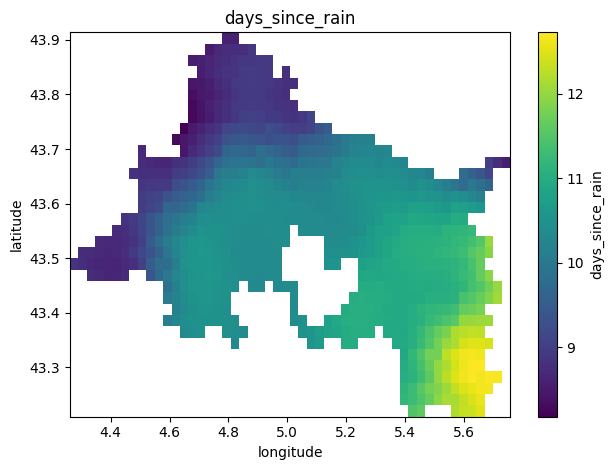

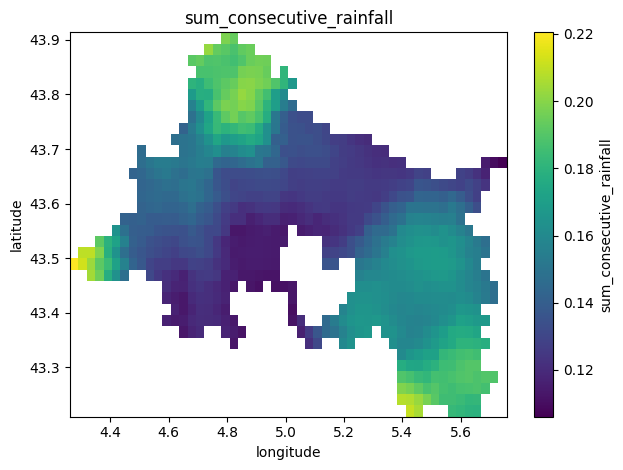

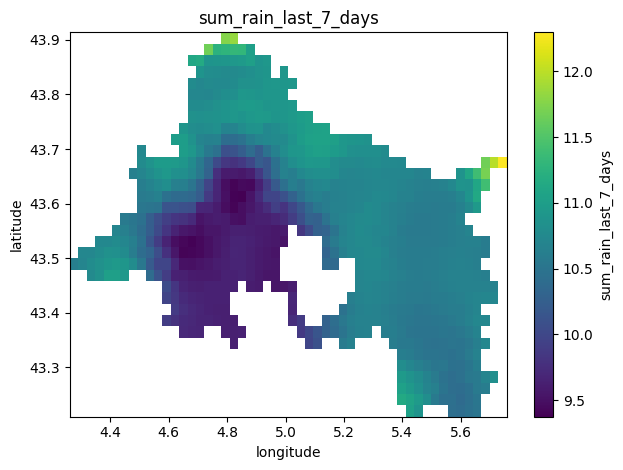

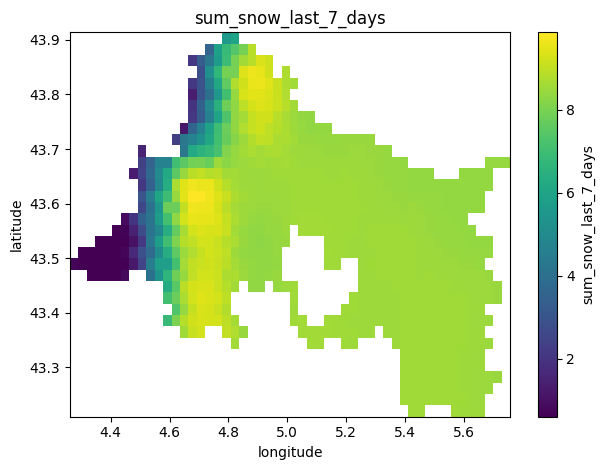

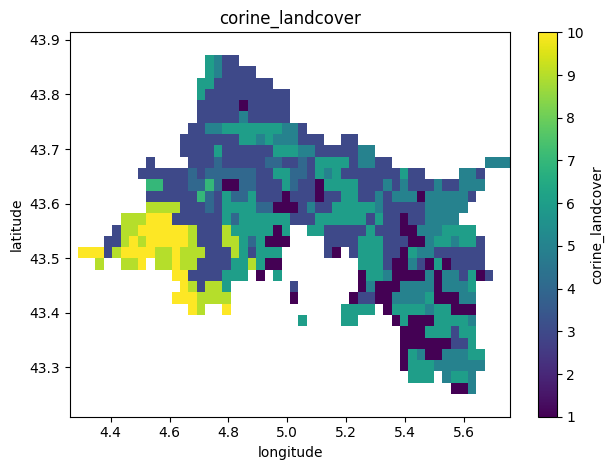

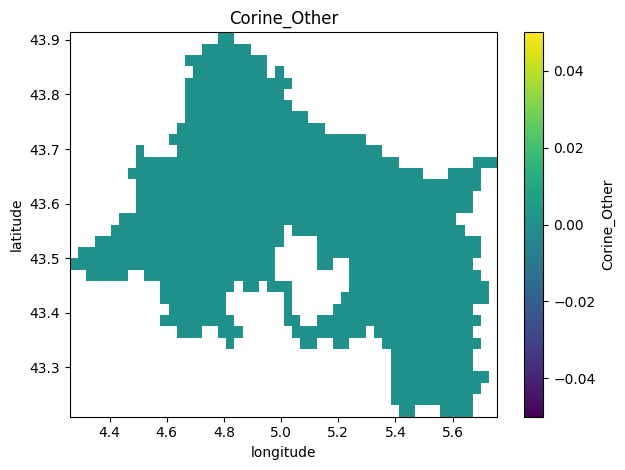

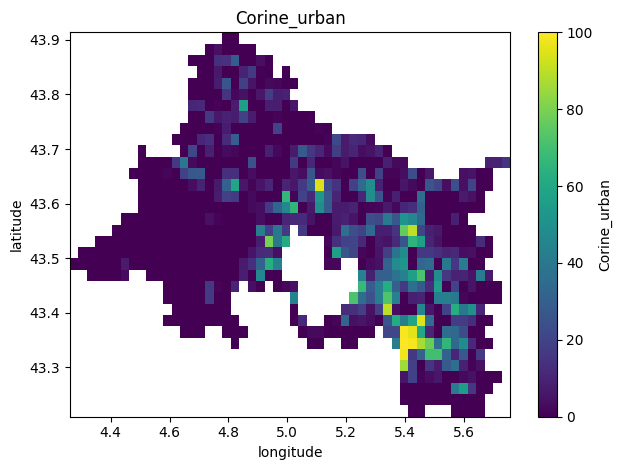

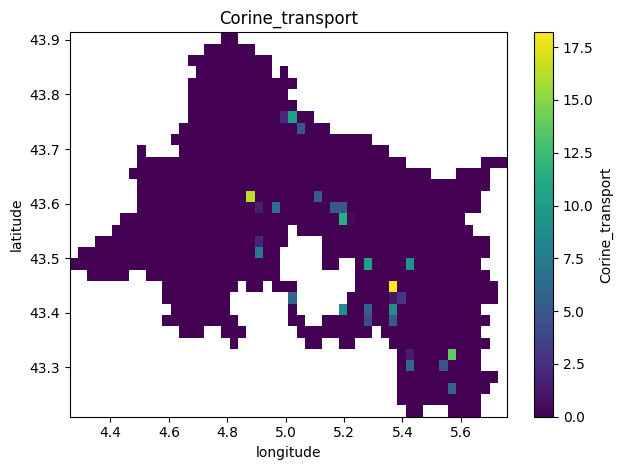

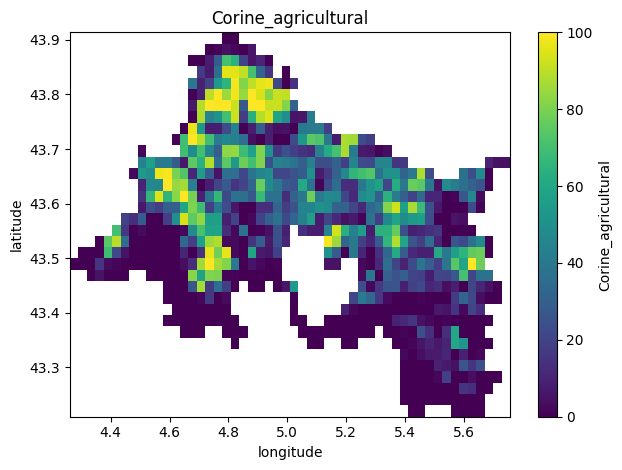

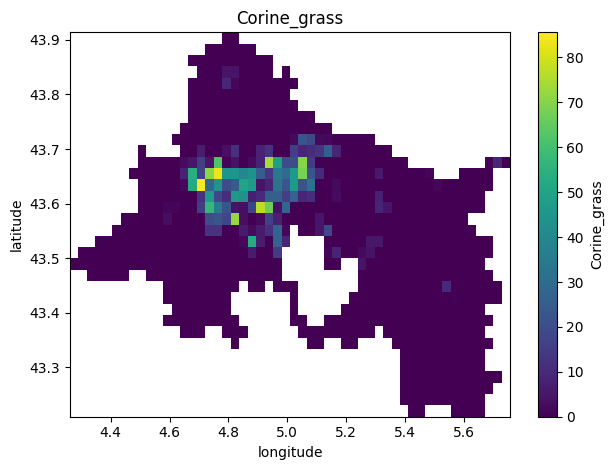

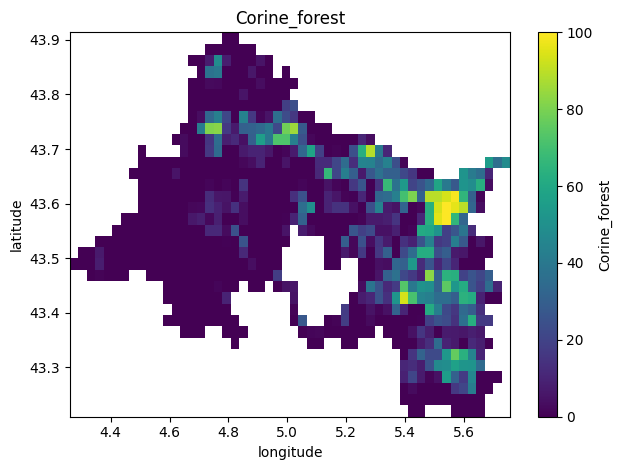

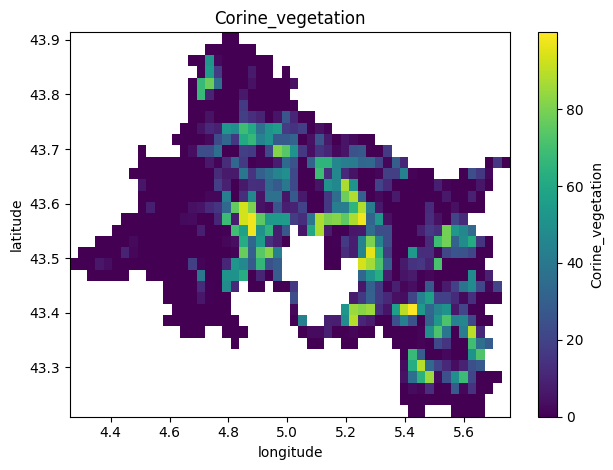

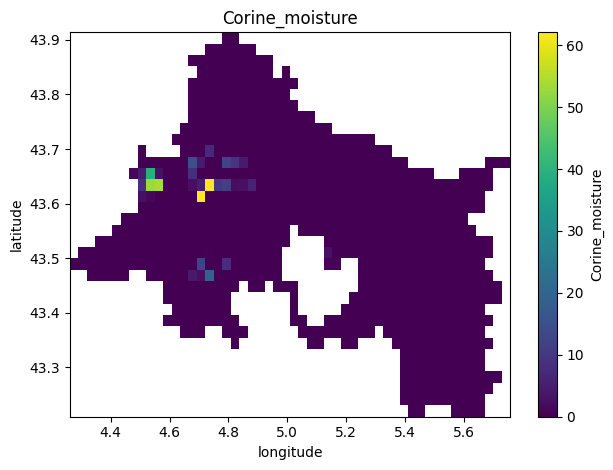

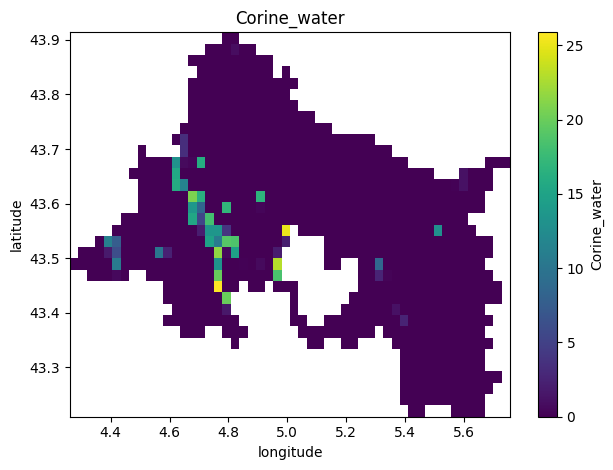

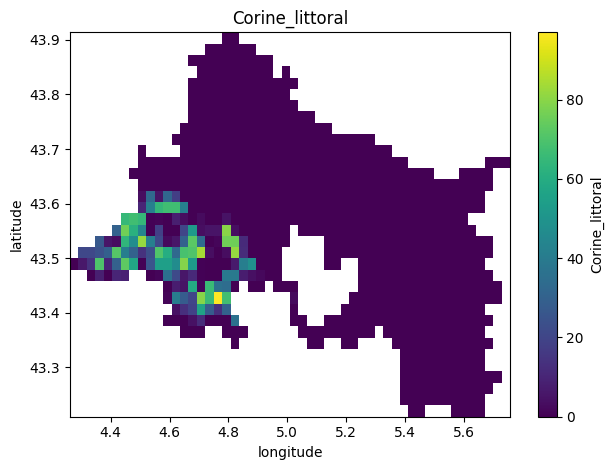

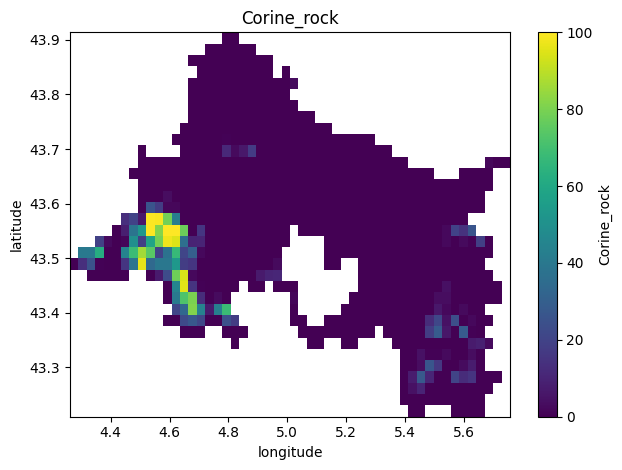

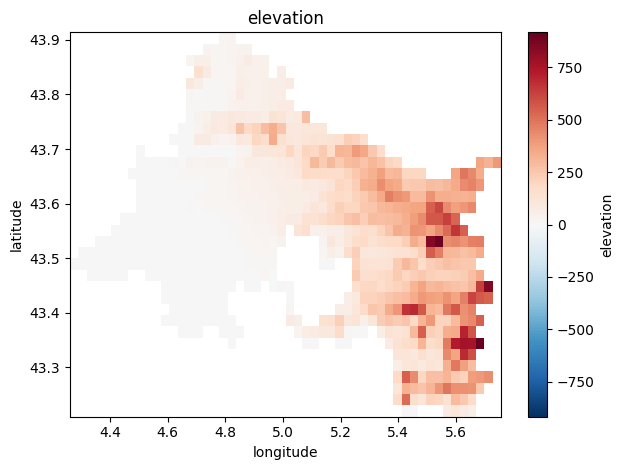

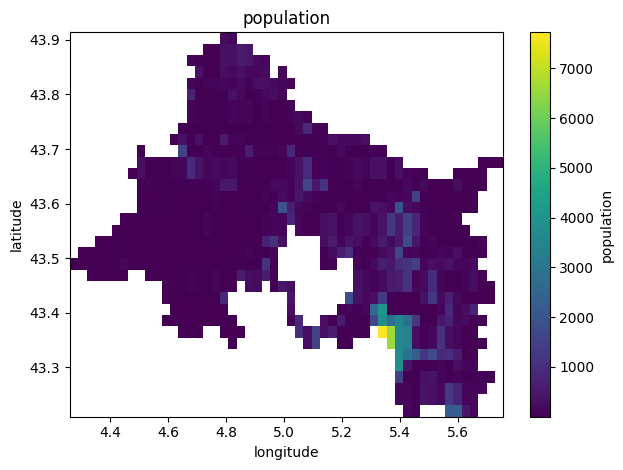

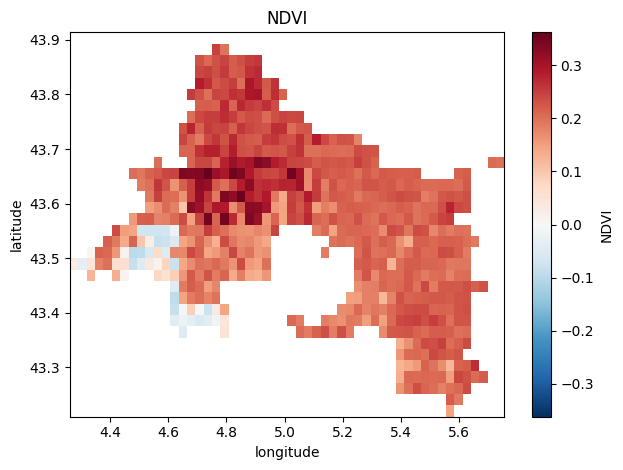

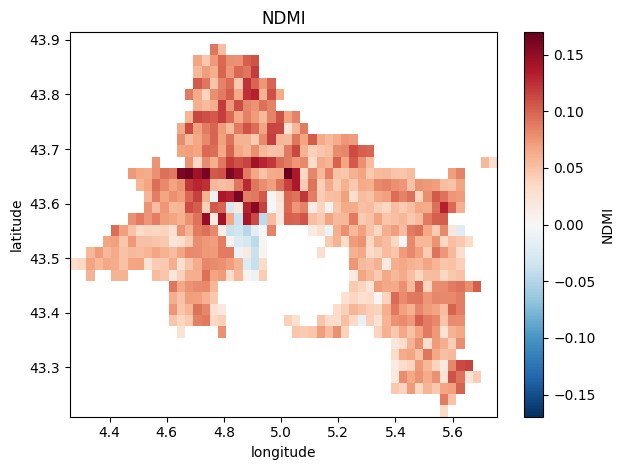

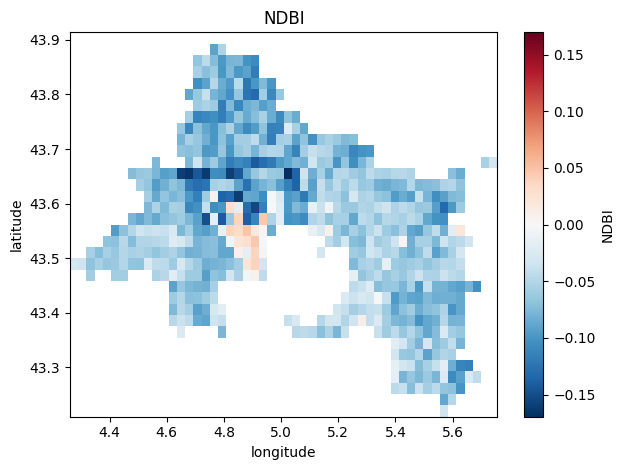

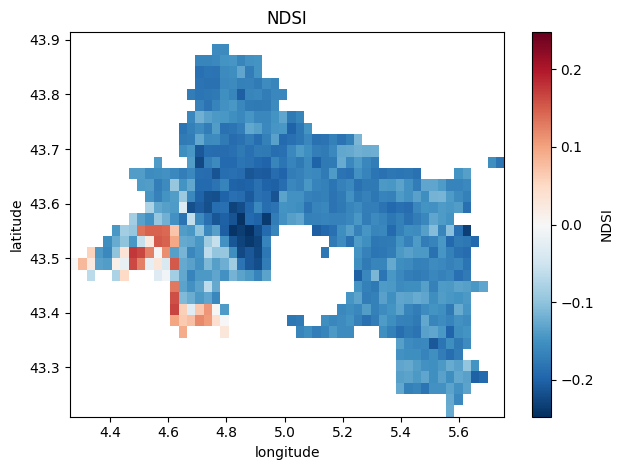

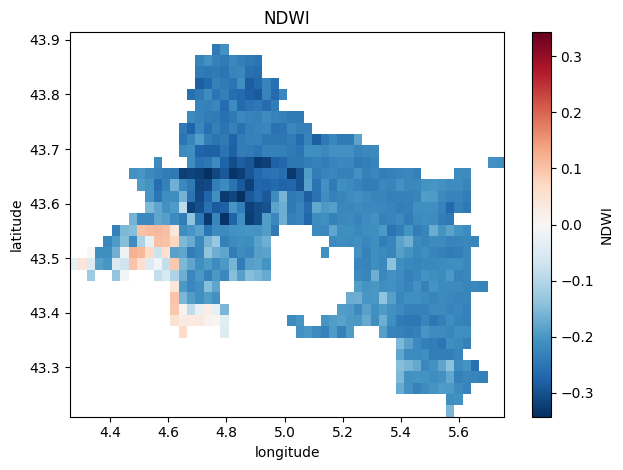

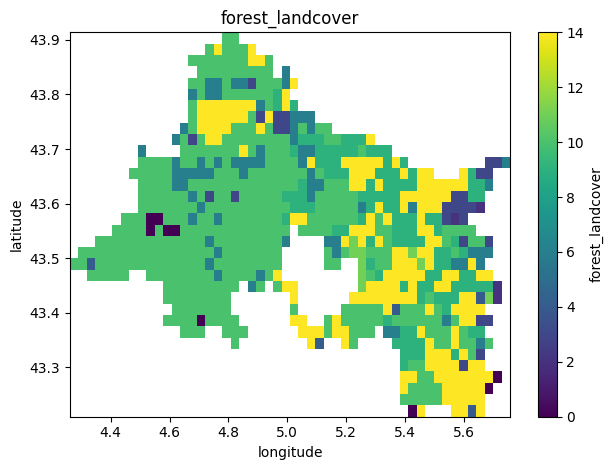

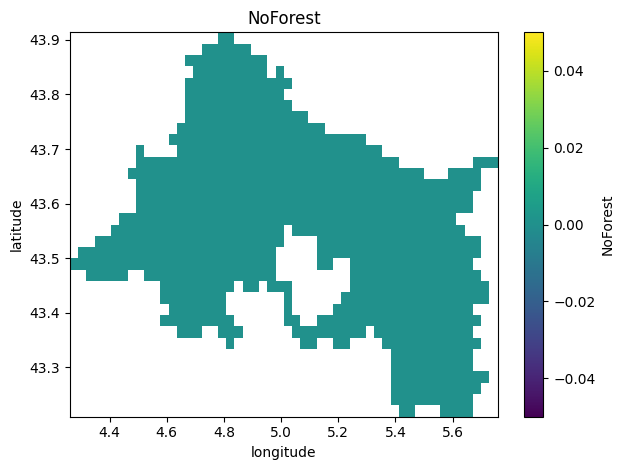

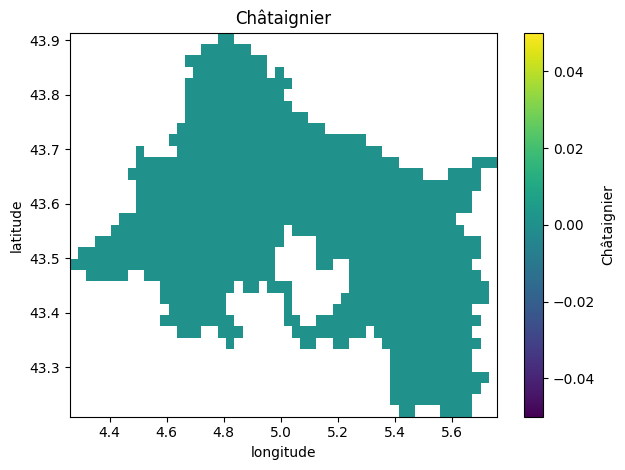

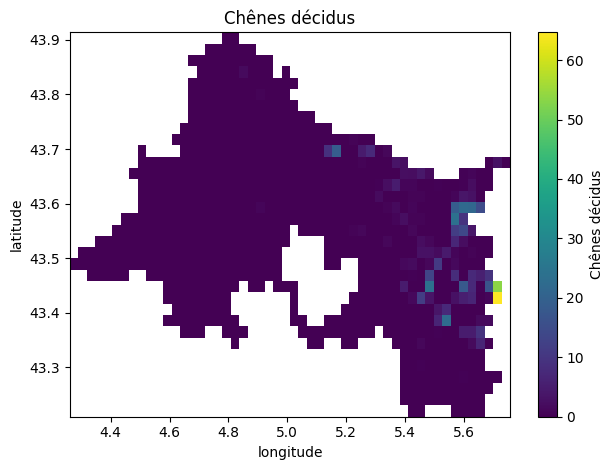

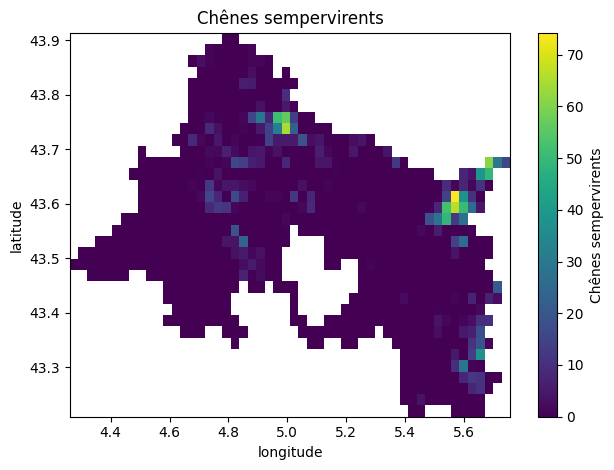

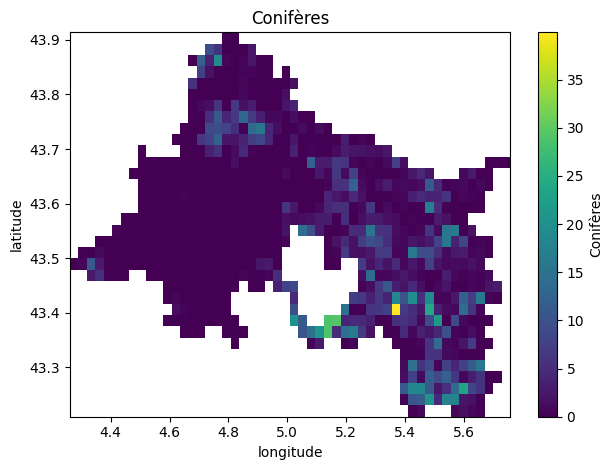

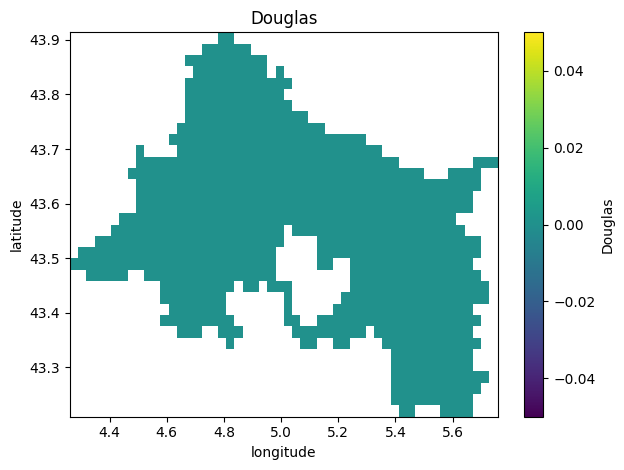

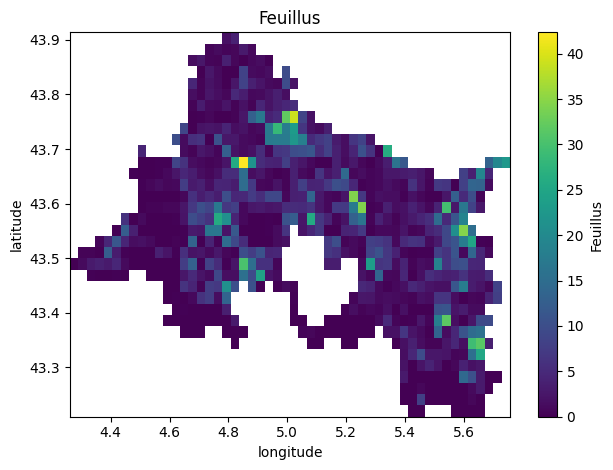

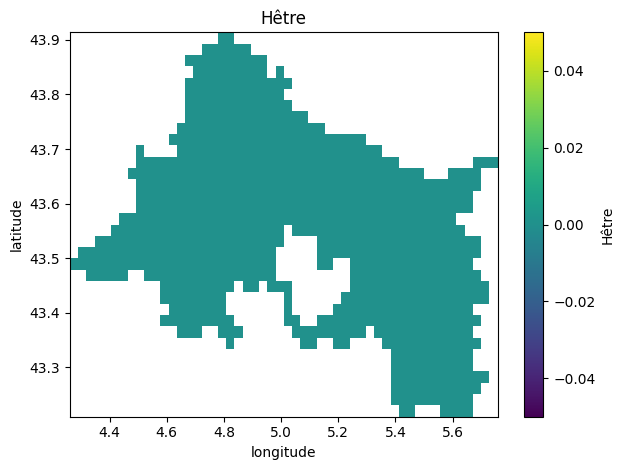

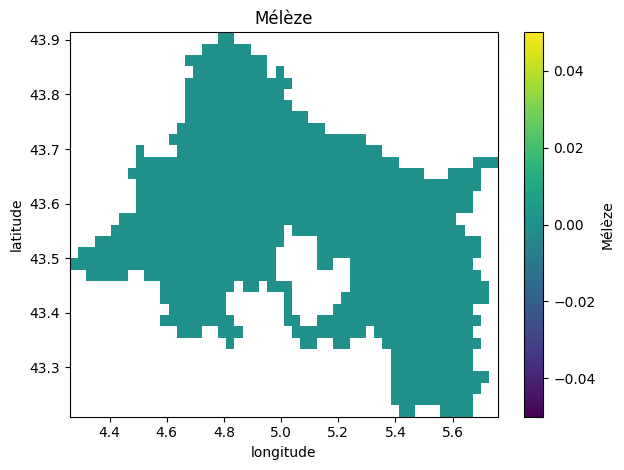

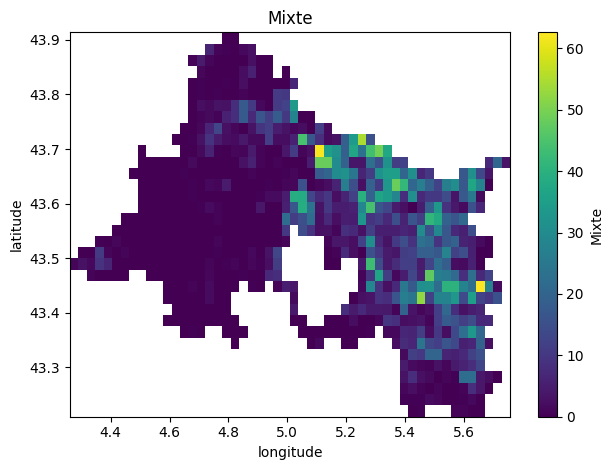

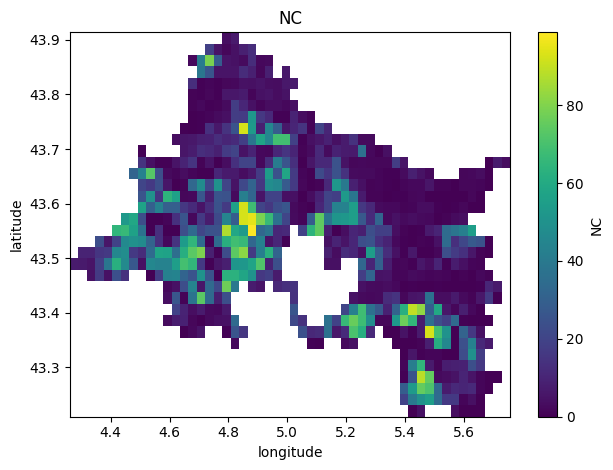

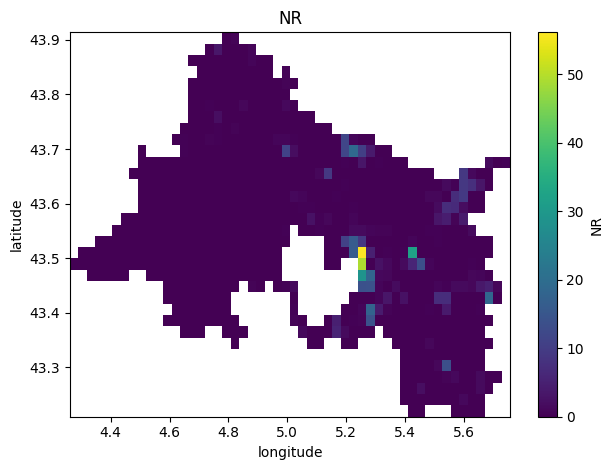

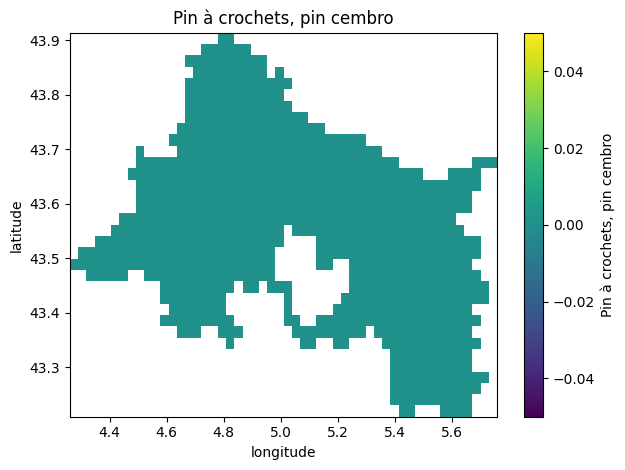

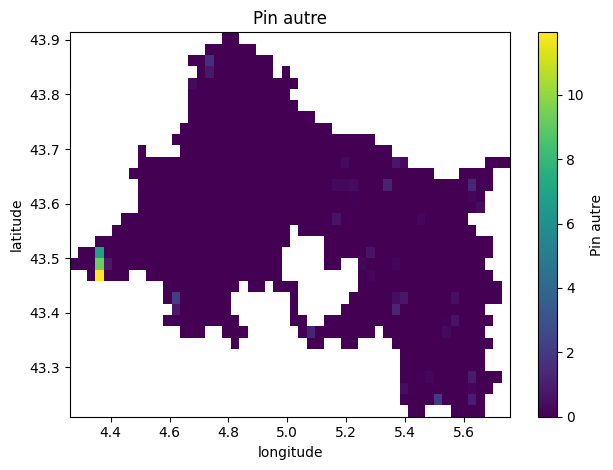

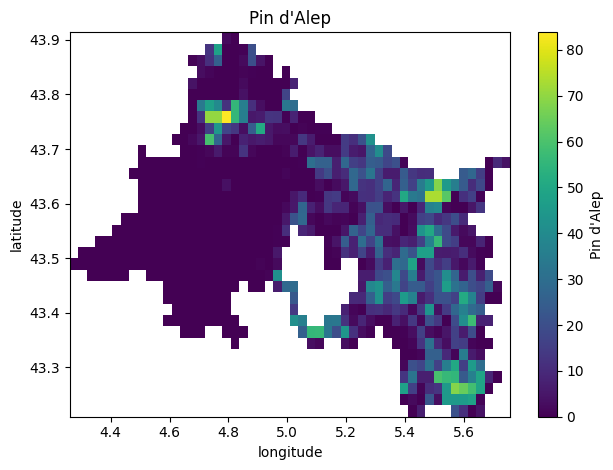

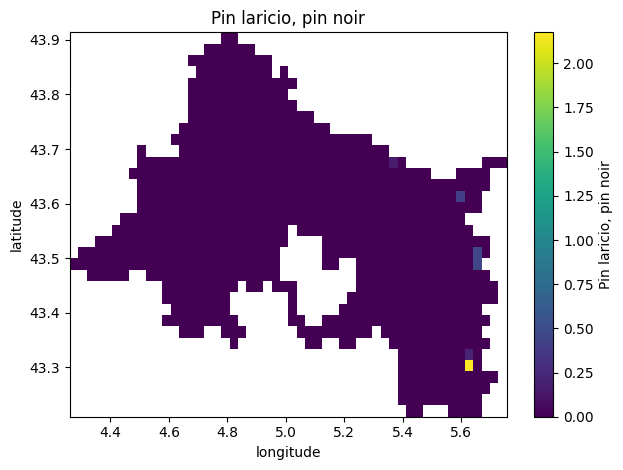

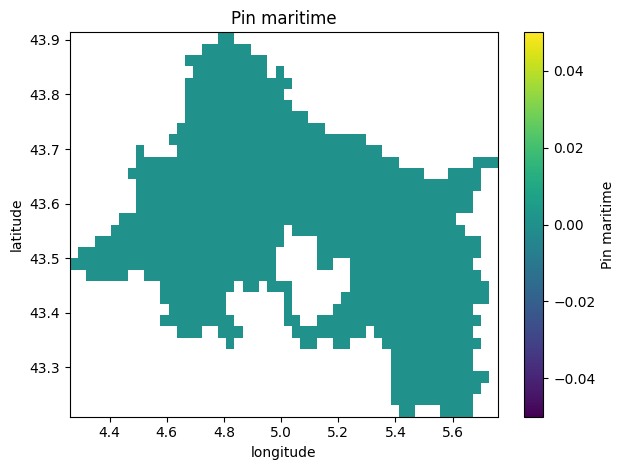

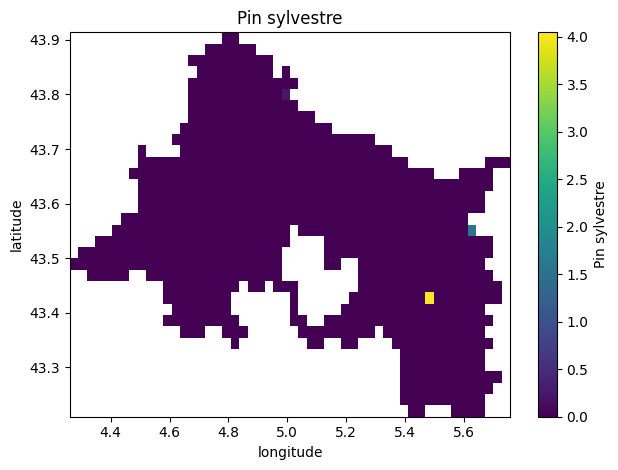

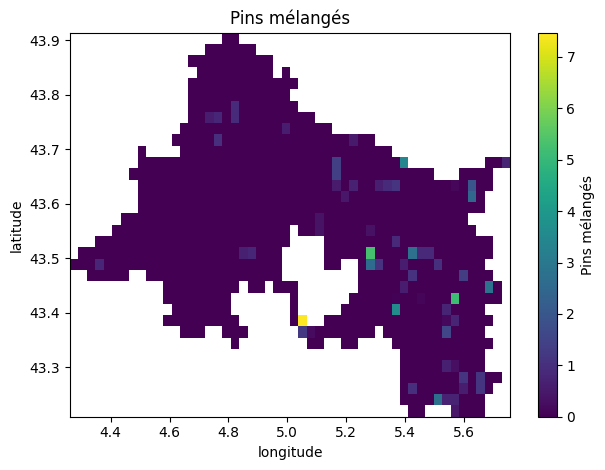

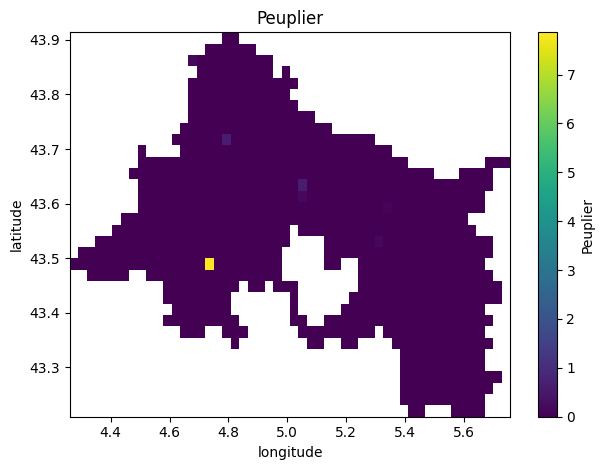

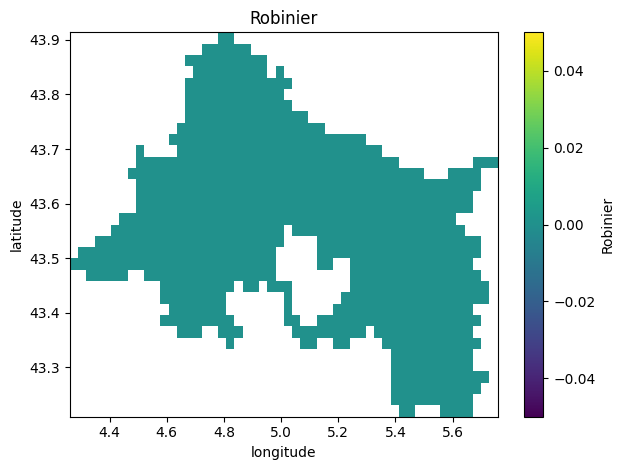

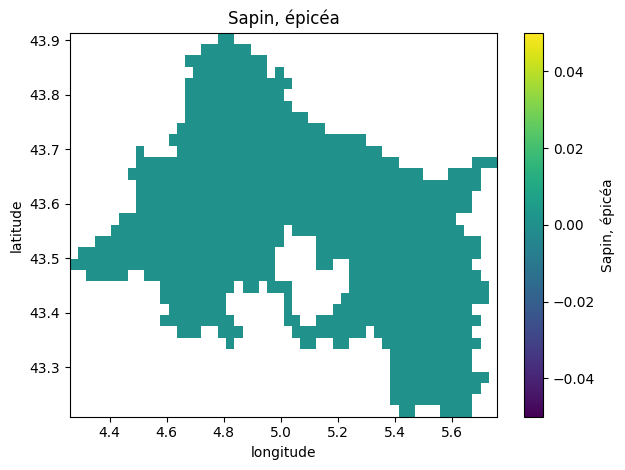

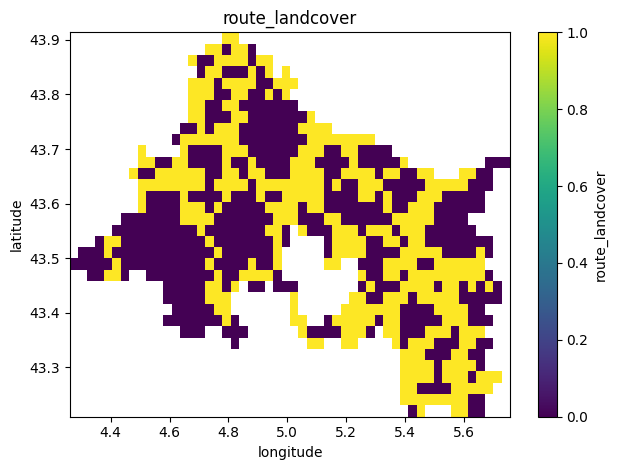

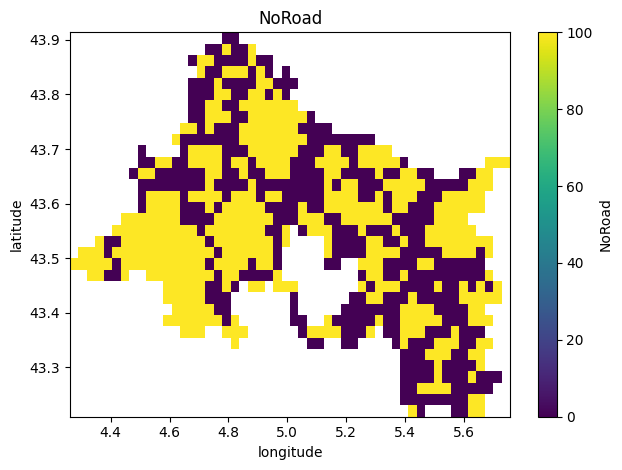

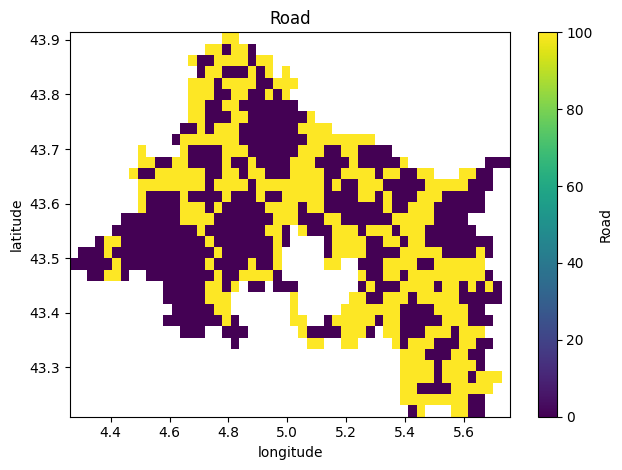

In [20]:
import xarray as xr
import matplotlib.pyplot as plt

def plot_latlon_vars(
    ds: xr.Dataset,
    cols : list,
    lat_name: str = "latitude",
    lon_name: str = "longitude",
    time_name: str = "date",
):
    for var_name, da in ds.data_vars.items():

        if var_name not in cols:
            continue
        
        if lat_name not in da.dims or lon_name not in da.dims:
            continue

        to_plot = da

        if time_name in to_plot.dims:
            to_plot = to_plot.mean(time_name, keep_attrs=True)

        extra_dims = [d for d in to_plot.dims if d not in (lat_name, lon_name)]
        if extra_dims:
            to_plot = to_plot.mean(extra_dims, keep_attrs=True)

        if set(to_plot.dims) != {lat_name, lon_name}:
            continue

        plt.figure()
        to_plot.plot(x=lon_name, y=lat_name)
        plt.title(var_name)
        plt.tight_layout()

    plt.show()

plot_latlon_vars(datacube, cols)